In [ ]:
from fastai.vision.all import *

In [ ]:
%env KAGGLE_USERNAME=sophiegilsten1
%env KAGGLE_KEY=4efa9652fff9ac287d8968c52ec13357

!kaggle datasets download phucthaiv02/butterfly-image-classification
!unzip butterfly-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/Image_2348.jpg    
  inflating: train/Image_2349.jpg    
  inflating: train/Image_235.jpg     
  inflating: train/Image_2350.jpg    
  inflating: train/Image_2351.jpg    
  inflating: train/Image_2352.jpg    
  inflating: train/Image_2353.jpg    
  inflating: train/Image_2354.jpg    
  inflating: train/Image_2355.jpg    
  inflating: train/Image_2356.jpg    
  inflating: train/Image_2357.jpg    
  inflating: train/Image_2358.jpg    
  inflating: train/Image_2359.jpg    
  inflating: train/Image_236.jpg     
  inflating: train/Image_2360.jpg    
  inflating: train/Image_2361.jpg    
  inflating: train/Image_2362.jpg    
  inflating: train/Image_2363.jpg    
  inflating: train/Image_2364.jpg    
  inflating: train/Image_2365.jpg    
  inflating: train/Image_2366.jpg    
  inflating: train/Image_2367.jpg    
  inflating: train/Image_2368.jpg    
  inflating: train/Image_2369.jpg    
  inflating: train/Image_237.jpg     

In [ ]:
path = Path(".")
path.ls()[2]

Path('Testing_set.csv')

In [ ]:
(path / 'train').ls()

(#6499) [Path('train/Image_3933.jpg'),Path('train/Image_1112.jpg'),Path('train/Image_1349.jpg'),Path('train/Image_196.jpg'),Path('train/Image_3509.jpg'),Path('train/Image_2043.jpg'),Path('train/Image_4396.jpg'),Path('train/Image_742.jpg'),Path('train/Image_6138.jpg'),Path('train/Image_3760.jpg'),Path('train/Image_3168.jpg'),Path('train/Image_3621.jpg'),Path('train/Image_314.jpg'),Path('train/Image_434.jpg'),Path('train/Image_903.jpg'),Path('train/Image_2726.jpg'),Path('train/Image_2398.jpg'),Path('train/Image_1414.jpg'),Path('train/Image_928.jpg'),Path('train/Image_770.jpg')...]

In [ ]:
path = Path(".")
files = (path / "train").ls()
small_path = Path("small_images")

resize_images(path / 'train', dest=small_path / 'train', max_size=256, recurse=True)
resize_images(path / 'test', dest=small_path / 'test', max_size=256, recurse=True)

In [ ]:
from fastai.vision.all import *
train_path = Path("small_images/train")
files = get_image_files(train_path)
print(f"Number of image files found: {len(files)}")
print("Sample file:", files[0] if len(files)>0 else "None found")

Number of image files found: 6499
Sample file: small_images/train/Image_3933.jpg


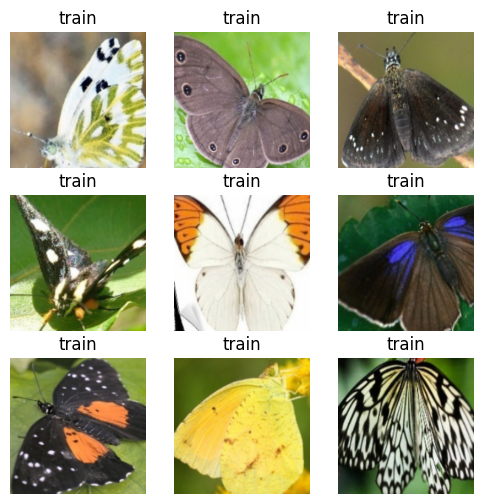

In [ ]:
dls.show_batch(max_n=9, figsize=(6,6))


In [ ]:
import os
os.listdir("small_images/train")[:10]

['Image_3933.jpg',
 'Image_1112.jpg',
 'Image_1349.jpg',
 'Image_196.jpg',
 'Image_3509.jpg',
 'Image_2043.jpg',
 'Image_4396.jpg',
 'Image_742.jpg',
 'Image_6138.jpg',
 'Image_3760.jpg']

In [ ]:
from fastai.vision.all import *
import pandas as pd

path = Path("small_images")
train_csv = path/'../Training_set.csv'
test_csv  = path/'../Testing_set.csv'

print(train_csv.exists(), test_csv.exists())

True True


In [ ]:
df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

df_train.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


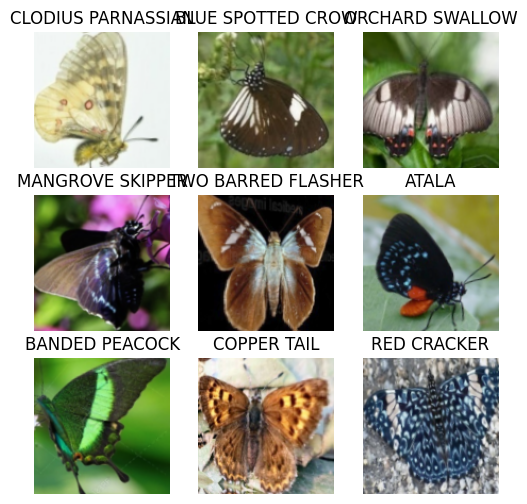

In [ ]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('filename', pref=path/'train/'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=314159),
    item_tfms=Resize(128),
    batch_tfms=aug_transforms(size=128)
)

dls = dblock.dataloaders(df_train, bs=32)
dls.show_batch(max_n=9, figsize=(6,6))

In [ ]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(5, base_lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.3MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,3.360355,1.457254,0.633564,00:17


epoch,train_loss,valid_loss,accuracy,time
0,1.632591,0.909850,0.754426,00:17
1,0.989134,0.617870,0.829869,00:17
2,0.625618,0.501346,0.859892,00:17
3,0.445222,0.452813,0.879138,00:19
4,0.395756,0.454978,0.882217,00:19


In [ ]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('filename', pref=path/'train/'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=314159),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)
dls = dblock.dataloaders(df_train, bs=16)

In [ ]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(10, base_lr=2e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.731491,0.879961,0.755966,00:31


epoch,train_loss,valid_loss,accuracy,time
0,0.720262,0.450417,0.866051,00:43
1,0.625067,0.417938,0.884527,00:43
2,0.599192,0.458615,0.887606,00:44
3,0.533465,0.412031,0.899153,00:43
4,0.367423,0.421887,0.906082,00:44
5,0.233333,0.371023,0.916859,00:43
6,0.156168,0.341374,0.935335,00:44
7,0.081347,0.345597,0.935335,00:43
8,0.052809,0.342949,0.936875,00:44
9,0.050581,0.337237,0.936105,00:43


In [ ]:
learn = vision_learner(dls, resnet50, metrics=accuracy)
learn.fine_tune(10, base_lr=2e-3)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.702700,0.889876,0.771363,00:53


epoch,train_loss,valid_loss,accuracy,time
0,0.728290,0.495596,0.873749,01:10
1,0.527327,0.467985,0.891455,01:10
2,0.359552,0.475352,0.890685,01:11
3,0.250491,0.394856,0.910701,01:10
4,0.239030,0.519288,0.920708,01:10
5,0.176510,0.474499,0.919169,01:11
6,0.105361,0.472060,0.923788,01:11
7,0.072545,0.404263,0.934565,01:10
8,0.046598,0.337054,0.937644,01:10
9,0.056751,0.359037,0.934565,01:11


In [ ]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('filename', pref=path/'train/'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=314159),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(
        size=224,
        max_rotate=30,
        max_zoom=1.2,
        max_lighting=0.3,
        max_warp=0.2,
        p_affine=0.9,
        p_lighting=0.9
    )
)
dls = dblock.dataloaders(df_train, bs=32)

In [ ]:
learn = vision_learner(dls, resnet50, metrics=accuracy)
learn.fine_tune(10, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,2.645777,1.024820,0.735951,00:57


epoch,train_loss,valid_loss,accuracy,time
0,1.116879,0.633367,0.837567,01:11
1,0.759594,0.473253,0.879908,01:10
2,0.480946,0.400710,0.896074,01:12
3,0.361804,0.371770,0.908391,01:10
4,0.257901,0.316215,0.916089,01:11
5,0.200233,0.331697,0.919938,01:10
6,0.144939,0.305183,0.926867,01:11
7,0.116359,0.303909,0.929176,01:10
8,0.097764,0.295189,0.931486,01:11
9,0.096858,0.297579,0.928406,01:10


In [ ]:
learn.unfreeze()
learn.fit_one_cycle(5, lr_max=slice(1e-5, 1e-4))

epoch,train_loss,valid_loss,accuracy,time
0,0.087080,0.310219,0.928406,01:11
1,0.090090,0.298533,0.933795,01:11
2,0.073369,0.292348,0.935335,01:10
3,0.065832,0.303634,0.933025,01:11
4,0.059806,0.298013,0.929176,01:10


In [ ]:
learn.fit_one_cycle(5, lr_max=slice(5e-6, 5e-5))

epoch,train_loss,valid_loss,accuracy,time
0,0.057379,0.291308,0.937644,01:10
1,0.057387,0.288688,0.942263,01:11
2,0.051779,0.288131,0.938414,01:10
3,0.057738,0.288968,0.941493,01:11
4,0.055032,0.288815,0.940724,01:10
